# Configuration

In [1]:
library(here)
library(tidyverse)
library(arrow)
library(skimr)
library(scales)
library(car)

source(here("src", "data_wrangling", "data_analysis.R"))

data_dir <- here("data", "intermediate", "whole_clinical_data.parquet")
output_dir <- here("results", "eda")

here() starts at C:/Users/Miguel/Desarrollo/TFM

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Adjuntando el paquete: 'arrow'


The following object is masked from 'package:lubridate':

    duration


The following object is masked from 'package:utils':

    timestamp



Adjuntando el paquete: 'scales'


The following object is masked from 'package:purrr':

    discard


The following object is masked from 'package:readr':

    col_factor


Cargando paquete requerido: carData


Adjuntando el paquete: 'car'


The fol

# Load the data

In [2]:
clinical_data <- read_parquet(data_dir)
head(clinical_data)

sex,age,smoking_status,code,center,intervention,BMI,WHR,Met,glucose,⋯,LAD,LAA,LAV,LVEF,AF_type,AF_ablation_time,previous_ablation,ERAF,AF_recurrence,hatch_score
<fct>,<dbl>,<ord>,<dbl>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<ord>,<fct>,<dbl>,<fct>,<fct>,<fct>,<dbl>
female,75.06,never,1013,Pamplona,intervention,37.57763,NA,4.841667,114.59,⋯,5.0,NA,35.0,normal,paroxysmal,4.3860369,no,no,no,2
male,28.01,never,1015,Pamplona,control,25.28011,0.5139665,36.714169,100.12,⋯,3.5,NA,56.0,normal,paroxysmal,0.3778234,no,no,no,0
female,70.10,never,1018,Pamplona,control,25.81663,0.5310734,11.582867,102.81,⋯,4.1,27.5,61.0,normal,persistent,0.3066393,no,no,no,0
male,73.40,current,1021,Pamplona,control,24.85795,0.5795455,39.271667,97.67,⋯,25.0,NA,24.7,normal,persistent,0.4763860,no,no,yes,0
male,66.01,never,1029,Pamplona,intervention,29.86055,NA,17.056667,82.60,⋯,42.0,NA,74.1,normal,persistent,9.1745377,yes,no,no,2
male,72.98,never,1030,Pamplona,control,23.98687,NA,23.619167,111.29,⋯,4.4,NA,NA,normal,persistent,2.6146474,yes,no,no,0


# Global summary
Let's check the column's data types and whether there are many missing values:

In [3]:
skim(clinical_data) |> summary()

── Data Summary ────────────────────────
                           Values       
Name                       clinical_data
Number of rows             720          
Number of columns          35           
_______________________                 
Column type frequency:                  
  factor                   22           
  numeric                  13           
________________________                
Group variables            None         

There are $720$ rows and $36$ columns: $22$ categorical (the target class can be found among these) and $14$ numeric features. Let's check each type separately.

## Numeric features

Let's sum up the data:

In [4]:
# Numeric features summary
num_features_summary <- clinical_data |> 
  select(-code) |> 
  
  # Compute summary statistics for numeric features
  skim() |> yank("numeric") |> 
  
  select(c(skim_variable, mean, sd, complete_rate)) |> 
  rename(feature = skim_variable) |> 
  
  # Replace the rate of complete values with the rate of missing values
  mutate(
    missing_rate = 1 - complete_rate,
    complete_rate = NULL
    )

print(num_features_summary, digits = 4)

# Save results
output_file <- here(output_dir, "num_features_summary.csv")

num_features_summary |> 
  write.csv(output_file, row.names = FALSE)


── Variable type: numeric ──────────────────────────────────────────────────────
   feature               mean      sd missing_rate
 1 age                 59.7   10.7          0     
 2 BMI                 27.8    4.15         0     
 3 waist_height_ratio   0.581  0.0792       0.232 
 4 Met                 34.8   22.2          0     
 5 glucose            102.    28.5          0.0417
 6 HDL                 46.8   23.6          0.103 
 7 triglicerides      103.    62.0          0.0972
 8 LAD                 16.0   17.3          0.526 
 9 LAA                 23.2    6.68         0.764 
10 LAV                 59.9   26.4          0.844 
11 AF_ablation_time     4.10   4.80         0     
12 hatch_score          0.925  1.09         0     


We will drop the features with $missing \ rate > 25 \%$:

In [5]:
num_features_summary |> 
  filter(missing_rate > 0.25) |> 
  select(c(feature, missing_rate))

feature,missing_rate
<chr>,<dbl>
LAD,0.5263889
LAA,0.7638889
LAV,0.8444444


Therefore, we will drop these features:

In [6]:
clinical_data <- clinical_data |>
  select(-c(LAD, LAA, LAV))

## Categorical features
Let's sum up the data:

In [7]:
# Categorical features summary
cat_features_summary <- clinical_data |> 
  select(-code) |> 
  
  # Compute summary statistics for categorical features
  skim() |> 
  yank("factor") |> 
  select(-c(complete_rate, ordered, top_counts)) |> 
  rename(feature = skim_variable) |> 
  mutate(
    missing_rate = n_missing/nrow(clinical_data),
    n_missing = NULL
    )

print(cat_features_summary, digits = 4)

# Save results
output_file <- here(output_dir, "cat_features_summary.csv")

cat_features_summary |> 
  write.csv(output_file, row.names = FALSE)


── Variable type: factor ───────────────────────────────────────────────────────
   feature              n_unique missing_rate
 1 sex                         2       0     
 2 smoking_status              3       0     
 3 center                      4       0     
 4 intervention                2       0     
 5 type1_diabetes              2       0     
 6 type2_diabetes              2       0     
 7 hypercholesterolemia        2       0     
 8 hypolipidemic_meds          2       0.0236
 9 OSA                         2       0     
10 renal_insuf                 2       0     
# ℹ 12 more rows


Using the same criteria as for the numeric features, we will drop those categorical features with $missing \ rate > 25 \%$:

In [8]:
cat_features_summary |> 
  filter(missing_rate > 0.25) |> 
  select(c(feature, missing_rate))

feature,missing_rate
<chr>,<dbl>


Since there are no categorical features with a $missing \ rate > 25 \%$, we will keep all of them.

# Missing values
Let's check the distribution of the missing values stratified by the target class:

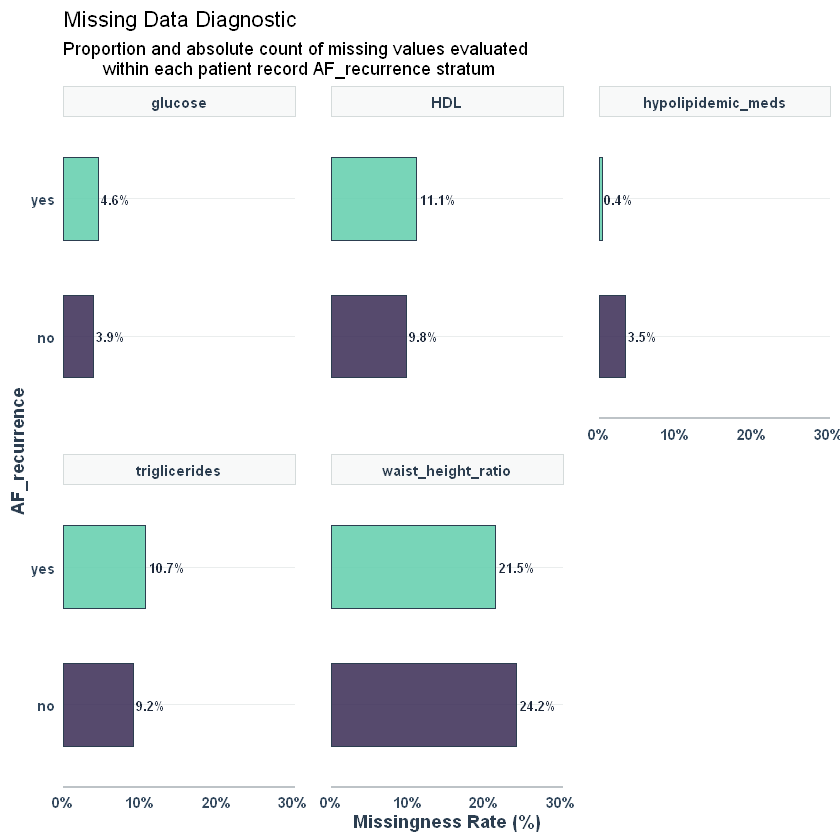

In [9]:
# Create the plot
NAs_by_AF_recurrence <- plot_stratified_missingness(clinical_data)

# Save the plot
save_plot(NAs_by_AF_recurrence, "NAs_stratified_by_AF_recurrence.png")

# Visualize the plot
NAs_by_AF_recurrence

There is no significant difference in the distribution of the missing values between the two classes, so we can assume that the data is missing completely at random (MCAR).

Furthermore, we will delete those records and features where $missing\_rate > 25 \%$:

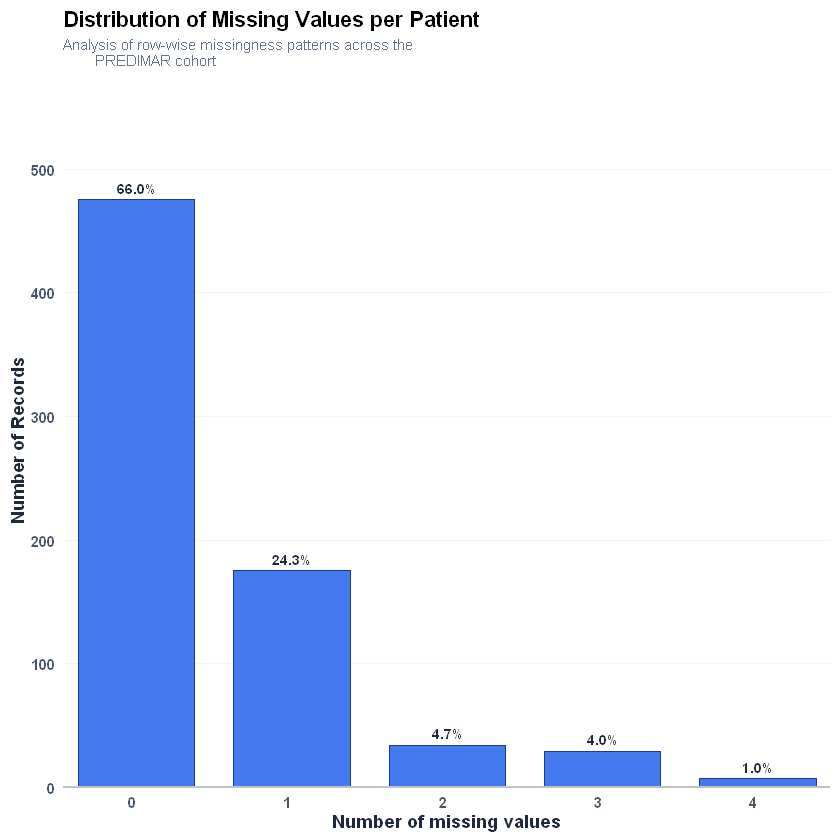

In [10]:
# Create the plot
NAs_by_row <- plot_row_missingness(clinical_data)

# Save the plot
save_plot(NAs_by_row, "NAs_stratified_by_row.png")

# Visualize the plot
NAs_by_row

Since there are no records with more than $5$ missing values ($missing \ rate < 1 \%$), we will keep all of them.

# Statistical analysis


## Numeric features

In [11]:
# Create the plot
global_numeric_distribution <- clinical_data |> 
  select(-c(code, hatch_score)) |> 
  plot_global_numeric_distribution()

# Save the plot
save_plot(
  plot = global_numeric_distribution,
  file_name = "numeric_distribution.png", 
  width = 8,
  height = 5
)

Numeric features distribution stratified by the target class:

In [12]:
# Create the plot
numeric_distribution_by_AF_recurrence <- clinical_data |> 
  select(-c(code, hatch_score)) |> 
  plot_stratified_numeric_distribution(target_var = "AF_recurrence")

# Save the plot
save_plot(
  plot = numeric_distribution_by_AF_recurrence, 
  file_name = "numeric_distribution_stratified_by_AF_recurrence.png",
  width = 8,
  height = 5
  )

Numeric features distribution stratified by the intervention feature:

In [13]:
# Create the plot
numeric_distribution_by_intervention <- clinical_data |> 
  select(-c(code, hatch_score)) |> 
  plot_stratified_numeric_distribution(target_var = "intervention")

# Save the plot
save_plot(
  plot = numeric_distribution_by_intervention,
  file_name = "numeric_distribution_stratified_by_intervention.png",
  width = 8,
  height = 5
  )

## Categorical features

Categorical features distribution:

In [14]:
# Create the plot
categorical_distribution <- clinical_data |> 
  plot_global_categorical_distribution()

# Save the plot
save_plot(
  plot = categorical_distribution,
  file_name = "categorical_distribution.png",
  width = 8,
  height = 8
)

Categorical features distribution stratified by the target class:

In [15]:
# Create the plot
categorical_distribution_by_AF_recurrence <- clinical_data |> 
  plot_stratified_categorical_distribution(target_var = "AF_recurrence")

# Save the plot
save_plot(
  plot = categorical_distribution_by_AF_recurrence,
  file_name = "categorical_distribution_stratified_by_AF_recurrence.png",
  width = 8,
  height = 12
)

Categorical features distribution stratified by the intervention variable:

In [16]:
# Create the plot
categorical_distribution_by_intervention <- clinical_data |> 
  plot_stratified_categorical_distribution(target_var = "intervention")

# Save the plot
save_plot(
  plot = categorical_distribution_by_intervention,
  file_name = "categorical_distribution_stratified_by_intervention.png",
  width = 8,
  height = 12
)

## Multicolinearity
Now, let's check the correlation between features.

### Numeric features
Correlation matrix of numeric features:

In [17]:
# Create the plot
numeric_correlation_matrix <- clinical_data |> 
  select(-code) |> 
  plot_corr_matrix(threshold = 0.5)

# Save the plot
save_plot(
  plot = numeric_correlation_matrix,
  file_name = "numeric_correlation_matrix.png",
  width = 8,
  height = 5
  )

Although the waist to height ratio might perform better as an obesity indicator (check the numeric distribution stratified by AF recurrence), the `BMI` feature's missing rate is $0$. Therefore, we will drop the `waist_height` feature:

In [18]:
clinical_data <- clinical_data |> 
  select(-waist_height_ratio)


### Categorical features
To address categorical features' colinearity, we will use **Cramer's V**.

In [19]:
# Create the plot
categorical_correlation_matrix <- clinical_data |> 
  plot_corr_matrix(dtype = "cat", threshold = 0.5) |> 
  suppressWarnings()

# Save the plot
save_plot(
  plot = categorical_correlation_matrix,
  file_name = "categorical_correlation_matrix.png",
  width = 8, 
  height = 5
  )

There is a perfect correlation between `heart_failure`-`LVEF` and a significant correlation between `hypolipidemic_meds`-`hypercholesterolemia`. Since the latter ones are more informative, we will drop `heart_failure` and `hypolipidemic_meds` feature.

In [20]:
clinical_data <- clinical_data |> 
  select(-c(heart_failure, hypolipidemic_meds))

### Global correlation
To address global colinearity, we will use the **Variance Inflation Factor**:

$$
VIF_i = \frac{1}{1 - R_i^2}
$$

Where $R_i^2$ is the determination coefficient of the regression of the $i$-th feature on the remaining features.

In [21]:
# Create plot 
VIF <- clinical_data |> 
    select(-code) |>
    plot_vif()

# Save the plot
save_plot(
    plot = VIF,
    file_name = "VIF.png",
    width = 8,
    height = 5
    )

Since $VIF < 5$ for all of the features, there is no more multicollinearity.

# Saving the data

In [22]:
file_path <- here("data", "clean", "whole_clinical_data.parquet")
write_parquet(
    clinical_data, 
    file_path
    )

head(clinical_data)

sex,age,smoking_status,code,center,intervention,BMI,Met,glucose,type1_diabetes,⋯,cardiomyopathy,antirrythmic_meds,LA_enlargment,LVEF,AF_type,AF_ablation_time,previous_ablation,ERAF,AF_recurrence,hatch_score
<fct>,<dbl>,<ord>,<dbl>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<fct>,⋯,<fct>,<fct>,<ord>,<ord>,<fct>,<dbl>,<fct>,<fct>,<fct>,<dbl>
female,75.06,never,1013,Pamplona,intervention,37.57763,4.841667,114.59,no,⋯,no,yes,severe,normal,paroxysmal,4.3860369,no,no,no,2
male,28.01,never,1015,Pamplona,control,25.28011,36.714169,100.12,no,⋯,no,no,mild,normal,paroxysmal,0.3778234,no,no,no,0
female,70.10,never,1018,Pamplona,control,25.81663,11.582867,102.81,no,⋯,no,no,mild,normal,persistent,0.3066393,no,no,no,0
male,73.40,current,1021,Pamplona,control,24.85795,39.271667,97.67,no,⋯,no,no,normal,normal,persistent,0.4763860,no,no,yes,0
male,66.01,never,1029,Pamplona,intervention,29.86055,17.056667,82.60,no,⋯,no,yes,severe,normal,persistent,9.1745377,yes,no,no,2
male,72.98,never,1030,Pamplona,control,23.98687,23.619167,111.29,no,⋯,no,no,mild,normal,persistent,2.6146474,yes,no,no,0
